Library

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

DATASET

In [51]:
df = pd.read_csv('plant_disease_dataset.csv')
df.head()

,temperature,humidity,rainfall,soil_pH,disease_present
0,27.483571,33.215053,0.572758,4.975875,1
1,24.308678,36.945005,42.522346,8.165266,0
2,28.238443,34.026189,16.095303,6.316734,1
3,32.615149,41.104180,20.311015,6.164949,0
4,23.829233,51.971785,11.851323,8.482468,0


DATA UNDERSTANDING

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   temperature      10000 non-null  float64
 1   humidity         10000 non-null  float64
 2   rainfall         10000 non-null  float64
 3   soil_pH          10000 non-null  float64
 4   disease_present  10000 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 390.8 KB


In [53]:
df.describe()

,temperature,humidity,rainfall,soil_pH,disease_present
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,25.612191,62.119300,9.807522,6.245855,0.241000
std,5.813841,22.679977,9.852130,1.302465,0.427712
min,5.387999,6.244209,0.000055,4.000075,0.000000
25%,21.815610,40.772925,2.812822,5.122970,0.000000
50%,25.293238,72.211752,6.864898,6.232188,0.000000
75%,28.916048,81.032999,13.442871,7.386377,0.000000
max,56.686495,102.395421,84.654161,8.499875,1.000000


In [54]:
df.isnull().sum()

,0
temperature,0
humidity,0
rainfall,0
soil_pH,0
disease_present,0


In [55]:
df.duplicated().sum()

np.int64(0)

EDA

Histogram

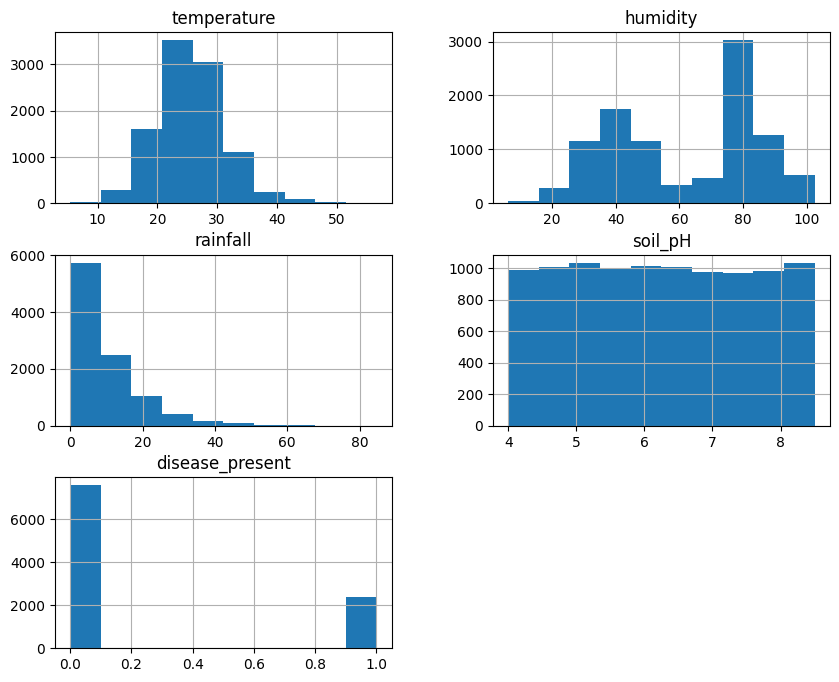

In [56]:
df.hist(figsize=(10,8))
plt.show()

Heatmap

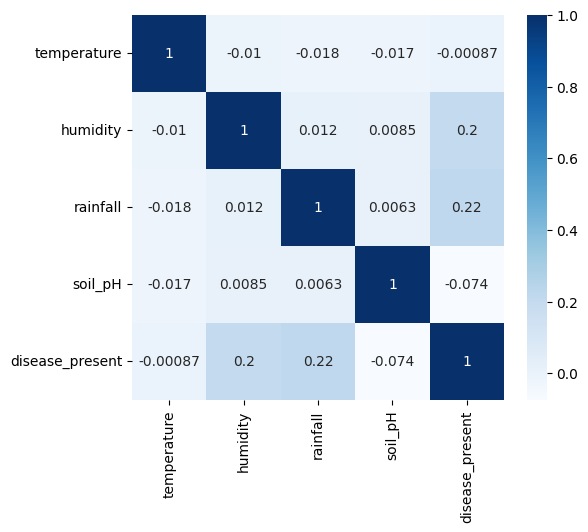

In [57]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(), annot=True, cmap='Blues')
plt.show()

DISTRIBUSI TARGET

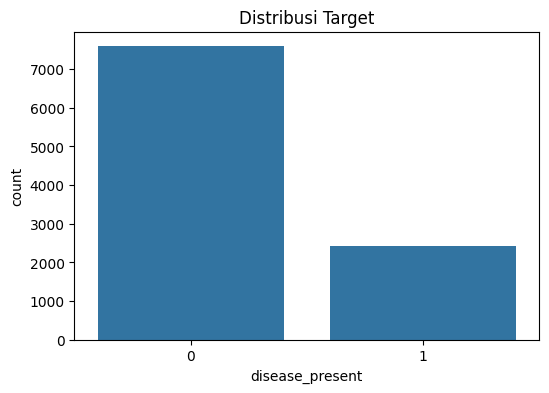

In [58]:
target_col = df.columns[-1]  # otomatis ambil kolom terakhir

plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Distribusi Target")
plt.show()

DATA PREPARATION

In [59]:
X = df.drop(df.columns[-1], axis=1)
y = df[df.columns[-1]]

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [61]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

DECISION TREE

In [62]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [63]:
print("Accuracy Decision Tree:", accuracy_score(y_test, dt_pred))

Accuracy Decision Tree: 0.772


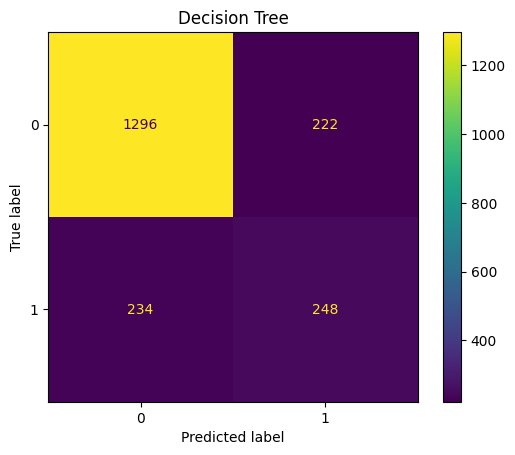

In [64]:
ConfusionMatrixDisplay.from_estimator(dt, X_test, y_test)
plt.title("Decision Tree")
plt.show()

In [65]:
from sklearn.metrics import classification_report

print("Classification Report Decision Tree")
print(classification_report(y_test, dt_pred))

Classification Report Decision Tree
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1518
           1       0.53      0.51      0.52       482

    accuracy                           0.77      2000
   macro avg       0.69      0.68      0.69      2000
weighted avg       0.77      0.77      0.77      2000



KNN

In [66]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

In [67]:
print("Accuracy KNN:", accuracy_score(y_test, knn_pred))

Accuracy KNN: 0.8325


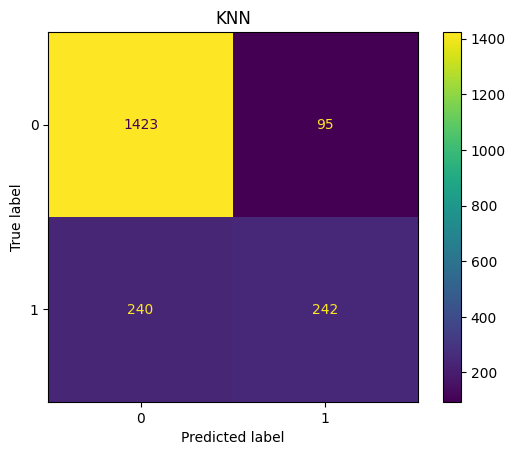

In [68]:
ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test)
plt.title("KNN")
plt.show()

In [71]:
from sklearn.metrics import classification_report

print("Classification Report Decision Tree")
print(classification_report(y_test, dt_pred))

Classification Report Decision Tree
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      1518
           1       0.53      0.51      0.52       482

    accuracy                           0.77      2000
   macro avg       0.69      0.68      0.69      2000
weighted avg       0.77      0.77      0.77      2000



PERBANDINGAN MODEL

In [69]:
hasil = pd.DataFrame({
    "Model": ["Decision Tree", "KNN"],
    "Accuracy": [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, knn_pred)
    ]
})

hasil

,Model,Accuracy
0,Decision Tree,0.7720
1,KNN,0.8325


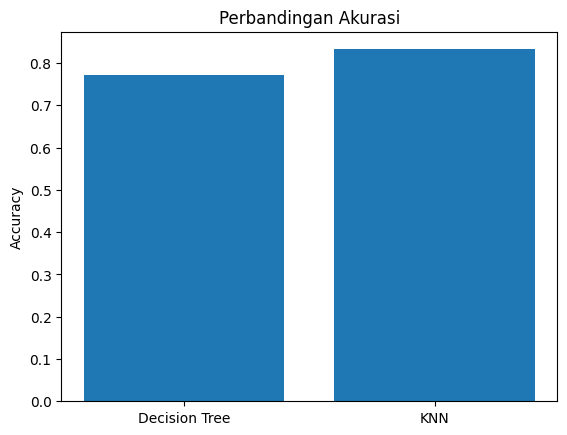

In [70]:
plt.bar(hasil["Model"], hasil["Accuracy"])
plt.title("Perbandingan Akurasi")
plt.ylabel("Accuracy")
plt.show()